### Test rmt

In [1]:
# import os

# os.environ["https_proxy"] = "127.0.0.1:2334"
from train_gym.rmt.rmt_wrappers import MemoryCell, RecurrentWrapper
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
import torch

# model_name = "alpindale/Llama-3.2-1B-Instruct"
# model_name = "gpt2"
# model_name = "openai-community/gpt2"
model_name = "model_checkpoints/gpt2"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    # torch_dtype=torch.bfloat16,
    torch_dtype=torch.float32,
    # attn_implementation="flash_attention_2",
    # device_map={"": 0},
)
model.cuda()
config = AutoConfig.from_pretrained(model_name)
# model = RMTForReasoning.from_pretrained(
#     model_name,
#     dtype=torch.bfloat16,
#     attn_implementation="flash_attention_2",
# )
cell = MemoryCell(
    model,
    # num_mem_tokens=16,
    num_mem_tokens=16,
)
model = RecurrentWrapper(
    cell,
    # segment_size=768,
    # segment_size=1024,
    segment_size=512,
    # max_n_segments=2,
    max_n_segments=32,
    # vary_n_segments=False,
    # vary_n_segments=True,
    k2=-1,
)
# model.load_state_dict(torch.load("/code/model_best.pt"))
tokenizer = AutoTokenizer.from_pretrained(model_name)

`torch_dtype` is deprecated! Use `dtype` instead!


In [2]:
# model.load_state_dict(torch.load("./model_best.pt"))
model.load_state_dict(torch.load("pytorch_model.bin"))

<All keys matched successfully>

In [ ]:
from torch import tensor

# tokenizer.padding_side = "right"
# tokenizer.padding_side = "left"
with torch.no_grad():
    model_inputs = tokenizer(
        # работает
        # "<context>\nSandra journeyed to the hallway. John went back to the garden. Daniel journeyed to the office. Mary journeyed to the bathroom. John went to the kitchen. Mary journeyed to the office. John journeyed to the bathroom. Sandra went to the office. Daniel moved to the hallway. John journeyed to the hallway.\n</context>\n\nQuestion: Where is John? ",
        # не работает
        # "<context>\nSandra journeyed to the hallway. John went back to the garden. Daniel journeyed to the office. Mary journeyed to the bathroom. John went to the kitchen. Mary journeyed to the office. John journeyed to the bathroom. Sandra went to the office. Daniel moved to the hallway. John journeyed to the hallway.\n</context>\n\nQuestion: Where is John?",
        # работает
        # '\n\n\n\n\n\n<context>\nChickens went; the\nfur and remains of little Rabbits were often found round the nest, and\npieces of meat disappeared from kitchen and larder. This went on for\nsome time, when suddenly the Cat disappeared--had been shot in a wood\nnear by, by a game-keeper, when hunting to provide for these wild\nkittens, which were allowed to live in the hedge, as they kept down the\nMice in the garden. This may be said to be a case of animal thieving\nfor a loftier purpose than generally obtains, mere demand for food and\nother necessity. That nature goes her own way is illustrated by these anecdotes of birds\nand animals, and by many others even more strange and convincing. The struggle for existence, like the brook, goes on forever, and the\nsurvival, if not of the fittest, at least of the strongest, must\ncontinue to be the rule of life, so long as the economical problems of\nexistence remain unsolved. Sandra travelled to the bathroom. "Manna," to some\nextent, will always be provided by generous humanitarianism. Occasionally a disinterested, self-abnegating\nsoul like that of John Woolman will appear among us--doing good from\nlove; and, it may be, men like Jonathan Chapman--Johnny Appleseed, he\nwas called from his habit of planting apple seeds whereever he went,\nas he distributed tracts among the frontier settlers in the early days\nof western history. His heart was\nright, though his judgment was little better than that of many modern\nsentimentalists who cannot apparently distinguish the innocuous from\nthe venemous. It does seem that birds and animals are warranted in committing every\nact of vandalism that they are accused of. They are unquestionably\nentitled by every natural right to everything of which they take\npossession. The farmer has no moral right to deny them a share in the\nproduct of his fields and orchards; the gardener is their debtor (at\nleast of the birds), and the government, which benefits also from their\nindustry, should give them its protection.--C. C. M.\n\n\n\n\nTHE PETRIFIED FERN. In a valley, centuries ago,\n      Grew a little fernleaf, green and slender,\n      Veining delicate and fibres tender,\n      Waving when the wind crept down so low;\n      Rushes tall, and moss, and grass grew round it;\n      Playful sunbeams darted in and found it,\n      Drops of dew stole in by night and crowned it;\n    But no foot of man e\'er came that way,\n    Earth was young and keeping holiday. Monster fishes swam the silent main--\n      Mountains hurled their snowy avalanches,\n      Giant forests shook their stately branches,\n    Mammoth creatures stalked across the plain;\n    Nature reveled in wild mysteries,\n    But the little fern was not of these,\n    Did not number with the hills and trees,\n      Only grew and waved its sweet wild way--\n      No one came to note it day by day. Earth one day put on a frolic mood,\n      Moved the hills and changed the mighty motion\n      Of the deep, strong currents of the ocean,\n    Heaved the rocks, and shook the haughty wood,\n      Crushed the little fern in soft moist clay,\n      Covered it and hid it safe away. Oh, the long, long centuries since that day! Oh, the agony, Oh, life\'s bitter cost\n    Since that useless little fern was lost! John went back to the office. There came a thoughtful man\n      Searching Nature\'s secrets far and deep;\n      From a fissure in a rocky steep\n    He withdrew a stone, o\'er which there ran\n      Fairy pencilings, a quaint design,\n      Veining, leafage, fibres, clear and fine,\n      And the fern\'s life lay in every line. So, methinks, God hides some souls away,\n    Sweetly to surprise us some sweet day. To show the importance of water to animal life, we give the opinions\nof several travelers and scientific men who have studied the question\nthoroughly. The Camel, with his pouch for storing water, can go longer without\ndrink than other animals. He doesn\'t do it from choice, any more than\nyou in a desert would prefer to drink the water that you have carried\nwith you, if you might choose between that and fresh spring water. Major A. G. Leonard, an English transport officer, claims that Camels\n"should be watered every day, that they can not be trained to do\nwithout water, and that, though they can retain one and a half gallons\nof water in the cells of the stomach, four or five days\' abstinence is\nas much as they can stand, in heat and with dry food, without permanent\ninjury." Bryden, has observed\nthat the beasts and birds of the deserts must have private stores of\nwater of which we know nothing. Bryden, however, has seen the\nSand-Grouse of South America on their flight to drink at a desert pool. "The watering process is gone through with perfect order and without\novercrowding"--a hint to young people who are hungry and thirsty at\ntheir meals. "From eight o\'clock to close on ten this wonderful flight\ncontinued; as birds drank and departed, others were constantly arriving\nto take their places. I should judge that the average time spent by\neach bird at and around the water was half an hour." To show the wonderful instinct which animals possess for discovering\nwater an anecdote is told by a writer in the _Spectator_, and the\narticle is republished in the _Living Age_ of February 5. The question\nof a supply of good water for the Hague was under discussion in Holland\nat the time of building the North Sea Canal. Some one insisted that\nthe Hares, Rabbits, and Partridges knew of a supply in the sand hills,\nbecause they never came to the wet "polders" to drink. Then one of the local engineers suggested that\nthe sand hills should be carefully explored, and now a long reservoir\nin the very center of those hills fills with water naturally and\nsupplies the entire town. All this goes to prove to our mind that if Seals do not apparently\ndrink, if Cormorants and Penguins, Giraffes, Snakes, and Reptiles seem\nto care nothing for water, some of them do eat wet or moist food, while\nthe Giraffe, for one, enjoys the juices of the leaves of trees that\nhave their roots in the moisture. None of these animals are our common,\neveryday pets. If they were, it would cost us nothing to put water\nat their disposal, but that they never drink in their native haunts\n"can not be proved until the deserts have been explored and the total\nabsence of water confirmed." --_Ex._\n\n\n\n\n  [Illustration: From col. CHICAGO COLORTYPE CO.,\n                 CHIC. Copyright by\n                 Nature Study Pub. Just how many species of Gulls there are has not yet been determined,\nbut the habits and locations of about twenty-six species have been\ndescribed. The American Herring Gull is found\n</context>\n\nQuestion: Where is Sandra?  ',
        # работает
        # '<context>\nAlfred turned to the officer, with a tone of command. "Wait," he said,\nthen he started toward the bedroom door to make sure that his other\nboy was quite safe. The picture that confronted him brought the hair\nstraight up on his head. True to her promise, and ignorant of Jimmy\'s\nreturn with the first baby, Aggie had chosen this ill-fated moment to\nappear on the threshold with one babe on each arm. "Here they are," she said graciously, then stopped in amazement at sight\nof the horrified Alfred, clasping a third infant to his breast. exclaimed Alfred, stroking his forehead with his unoccupied\nhand, and gazing at what he firmly believed must be an apparition,\n"THOSE aren\'t MINE," he pointed to the two red mites in Aggie\'s arms. stammered Aggie for the want of something better\nto say. Then he turned in appeal to his young wife,\nwhose face had now become utterly expressionless. There was an instant\'s pause, then the blood returned to Zoie\'s face and\nshe proved herself the artist that Alfred had once declared her. "OURS, dear," she murmured softly, with a bashful droop of her lids. persisted Alfred, pointing to the baby in his arms, and\nfeeling sure that his mind was about to give way. "Why--why--why," stuttered Zoie, "THAT\'S the JOKE." echoed Alfred, looking as though he found it anything but\nsuch. "Yes," added Aggie, sharing Zoie\'s desperation to get out of their\ntemporary difficulty, no matter at what cost in the future. stammered Alfred, "what IS there to tell?" "Why, you see," said Aggie, growing more enthusiastic with each\nelaboration of Zoie\'s lie, "we didn\'t dare to break it to you too\nsuddenly." gasped Alfred; a new light was beginning to dawn on\nhis face. Sandra journeyed to the garden. "So," concluded Zoie, now thoroughly at home in the new situation, "we\nasked Jimmy to take THAT one OUT." Jimmy cast an inscrutable glance in Zoie\'s direction. Was it possible\nthat she was at last assisting him out of a difficulty? "Yes," confirmed Aggie, with easy confidence, "we wanted you to get used\nto the idea gradually." He was afraid to allow his mind to accept\ntoo suddenly the whole significance of their disclosure, lest his joy\nover-power him. "You--you--do--don\'t mean----" he stuttered. "Yes, dear," sighed Zoie, with the face of an angel, and then with a\nlanguid sigh, she sank back contentedly on her pillows. cried Alfred, now delirious with delight. "Give\nthem to me," he called to Aggie, and he snatched the surprised infants\nsavagely from her arms. "Give me ALL of them, ALL of them." He clasped\nthe three babes to his breast, then dashed to the bedside of the\nunsuspecting Zoie and covered her small face with rapturous kisses. Feeling the red faces of the little strangers in such close proximity to\nhers, Zoie drew away from them with abhorrence, but unconscious of her\nunmotherly action, Alfred continued his mad career about the room, his\nheart overflowing with gratitude toward Zoie in particular and mankind\nin general. Finding Aggie in the path of his wild jubilee, he treated\nthat bewildered young matron to an unwelcome kiss. A proceeding which\nJimmy did not at all approve. Hardly had Aggie recovered from her surprise when the disgruntled\nJimmy was startled out of his dark mood by the supreme insult of a\nloud resounding kiss implanted on his own cheek by his excitable young\nfriend. Jimmy raised his arm to resist a second assault, and Alfred\nveered off in the direction of the officer, who stepped aside just in\ntime to avoid similar demonstration from the indiscriminating young\nfather. Finding a wide circle prescribed about himself and the babies, Alfred\nsuddenly stopped and gazed about from one astonished face to the other. In the mural paintings at Chichen-Itza, we again find the baboon\n(Cynocephalus) warning Moo of impending danger. She is pictured in her\nhome, which is situated in the midst of a garden, and over which is seen\nthe royal insignia. A basket, painted blue, full of bright oranges, is\nsymbolical of her domestic happiness. Before\nher is an individual pictured physically deformed, to show the ugliness\nof his character and by the flatness of his skull, want of moral\nqualities, (the[TN-36] proving that the learned men of Mayab understood\nphrenology). He is in an persuasive attitude; for he has come to try to\nseduce her in the name of another. She rejects his offer: and, with her\nextended hand, protects the armadillo, on whose shell the high priest\nread her destiny when yet a child. In a tree, just above the head of the\nman, is an ape. His hand is open and outstretched, both in a warning and\nthreatening position. Daniel journeyed to the garden. A serpent (_can_), her protecting spirit, is seen\nat a short distance coiled, ready to spring in her defense. Near by is\nanother serpent, entwined round the trunk of a tree. He has wounded\nabout the head another animal, that, with its mouth open, its tongue\nprotruding, looks at its enemy over its shoulder. Blood is seen oozing\nfrom its tongue and face. This picture forcibly recalls to the mind the\nmyth of the garden of Eden. For here we have the garden, the fruit, the\nwoman, the tempter. As to the charmed _leopard_ skin worn by the African warriors to render\nthem invulnerable to spears, it would seem as if the manner in which\nChaacmol met his death, by being stabbed with a spear, had been known\nto their ancestors; and that they, in their superstitious fancies, had\nimagined that by wearing his totem, it would save them from being\nwounded with the same kind of weapon used in killing him. Let us not\nlaugh at such a singular conceit among uncivilized tribes, for it still\nprevails in Europe. On many of the French and German soldiers, killed\nduring the last German war, were found talismans composed of strips of\npaper, parchment or cloth, on which were written supposed cabalistic\nwords or the name of some saint, that the wearer firmly believed to be\npossessed of the power of making him invulnerable. I am acquainted with many people--and not ignorant--who believe that by\nwearing on their persons rosaries, made in Jerusalem and blessed by the\nPope, they enjoy immunity from thunderbolts, plagues, epidemics and\nother misfortunes to which human flesh is heir. That the Mayas were a race autochthon on this western continent and did\nnot receive their civilization from Asia or Africa, seems a rational\nconclusion, to be deduced from the foregoing FACTS. If we had nothing\nbut their _name_ to prove it, it should be sufficient, since its\netymology is only to be found in the American Maya language. They cannot be said to have been natives of Hindostan; since we are told\nthat, in very remote ages, _Maya_, a prince of the Davanas, established\nhimself there. We do not find the etymology of his name in any book\nwhere mention is made of it. We are merely told that he was a wise\nmagician, a great architect, a learned astronomer, a powerful Asoura\n(demon), thirsting for battles and bloodshed: or, according to the\nSanscrit, a Goddess, the\n</context>\n\nQuestion: Where is Daniel? ',
        # не работает
        # '<context>\nMaurice Heywood refused to\nmire his horse for a whim. In a rare flush of pride, Rudolph wheeled his stubborn mount and bullied\nhim down the bank. A poor horseman, he would have outstripped Curtius to\nthe gulf. But no sooner had his dancing pony consented to make the first\nrebellious, sidelong plunge, than he had small joy of his boast. Fore-legs sank floundering, were hoisted with a terrified wrench of the\nshoulders, in the same moment that hind-legs went down as by suction. The pony squirmed, heaved, wrestled in a frenzy, and churning the red\nwater about his master\'s thighs, went deeper and fared worse. With a\nclangor of wings, the storks rose, a streaming rout against the sky,\ntrailed their tilted legs, filed away in straggling flight, like figures\ninterlacing on a panel. At the height of his distress, Rudolph caught a\nwhirling glimpse of the woman above him, safe on firm earth, easy in her\nsaddle, and laughing. Quicksand, then, was a joke,--but he could not\npause for this added bewilderment. The pony, using a skill born of agony, had found somewhere a solid verge\nand scrambled up, knee-deep, well out from the bank. With a splash,\nRudolph stood beside him among the tufts of salad green. As he patted\nthe trembling flanks, he heard a cry from the shore. She might laugh, but now he\nwould see this folly through. He tore off his coat, flung it across the\nsaddle, waded out alone through the tussocks, and shooting forward full\nlength in the turbid water, swam resolutely for the island. Sky and water brightened while he swam; and as he rose, wrapped in the\nleaden weight of dripping clothes, the sun, before and above him,\ntouched wonderfully the quaggy bank and parched grasses. He lurched\nashore, his feet caked with enormous clods as of melting chocolate. A\nfilthy scramble left him smeared and disheveled on the summit. The mound lay vacant, a tangled patch, a fragment of\nwilderness. Yet as he stood panting, there rose a puny, miserable sound. The distress, it might be, of some small\nanimal--a rabbit dying in a forgotten trap. Faint as illusion, a wail, a\nthin-spun thread of sorrow, broke into lonely whimpering, and ceased. Sandra went back to the bathroom. He\nmoved forward, doubtfully, and of a sudden, in the scrubby level of the\nisle, stumbled on the rim of a shallow circular depression. At first, he could not believe the discovery; but next instant--as at\nthe temple pond, though now without need of placard or interpreter--he\nunderstood. This bowl, a tiny crater among the weeds, showed like some\npaltry valley of Ezekiel, a charnel place of Herod\'s innocents, the\nbattlefield of some babes\' crusade. A chill struck him, not from the\nwater or the early mists. In stupor, he viewed that savage fact. Through the stillness of death sounded again the note of living\ndiscontent. He was aware also of some stir, even before he spied, under\na withered clump, the saffron body of an infant girl, feebly squirming. By a loathsome irony, there lay beside her an earthen bowl of rice, as\nan earnest or symbol of regret. Sandra journeyed to the office. Blind pity urged him into the atrocious hollow. Seeing no further than\nthe present rescue, he caught up the small unclean sufferer, who moaned\nthe louder as he carried her down the bank, and waded out through the\nsludge. Mary travelled to the hallway. To hold the squalling mouth above water, and swim, was no simple\nfeat; yet at last he came floundering among the tussocks, wrapped the\nnaked body in his jacket, and with infinite pains tugged his terrified\npony along a tortuous bar to the land. Once in the river-path, he stood gloomily, and let Mrs. Forrester canter\nup to join him. But what can you have\nbrought back? He turned on her a muddy, haggard face, without enthusiasm, and gently\nunfolded the coat. The man and the woman looked down together, in\nsilence, at the child. Daniel went to the office. He had some foolish hope that she would take it,\nthat his part was ended. Like an outlandish doll, with face contorted\nand thick-lidded eyes shut tightly against the sunshine, the outcast\nwhimpered, too near the point of death for even the rebellion of\narms and legs. The woman in the saddle gave a short, incredulous cry. Her face, all gay\ncuriosity, had darkened in a shock of disgust. Such a nasty little--Why\ndid--What do you propose doing with it?" Rudolph shook his head, like a man caught in some stupid blunder. "I never thought of that," he explained heavily. With a sombre, disappointed air, he obeyed; then looked up, as if in her\nface he read strange matter. Mary journeyed to the garden. "I can\'t bear," she added quickly, "to see any kind of suffering. Why\ndid--It\'s all my fault for sending you! We were having such a good ride\ntogether, and now I\'ve spoiled it all, with this.--Poor little filthy\nobject!" She turned her hands outward, with a helpless, dainty gesture. His thoughts, then, had wronged\nher. Drenched and downhearted, holding this strange burden in his\njacket, he felt that he had foolishly meddled in things inevitable,\nbeyond repair. Yet some vague, insurgent instinct, which\nwould not down, told him that there had been a disappointment. Then suddenly he mounted, bundle and all, and turned his willing pony\nhomeward. "Come," he said; and for the first time, unwittingly, had taken charge. Without waiting, he beckoned her to follow. They rode stirrup to stirrup, silent as in their escape at\ndawn, and as close bodily, but in spirit traveling distant parallels. He\ngave no thought to that, riding toward his experiment. Near the town, at\nlast, he reined aside to a cluster of buildings,--white walls and rosy\ntiles under a great willow. "You may save your steps," she declared, with sudden petulance. "The\nhospital\'s more out of funds than ever, and more crowded. Rudolph nodded back at her, with a queer smile, half reckless and half\nconfident. "Then," he replied, dismounting, "I will replenish my nunnery." John travelled to the office. Squatting coolies sprang up and raced to hold his pony. Others, in the\nshade of the wall, cackled when they saw a Son of the Red-Haired so\nbeplastered and sopping. A few pointed at his bundle, with grunts of\nsudden interest; and a leper, bearing the visage as of a stone lion\ndefaced by time, cried something harshly. At his words, the whole band\nof idlers began to chatter. An\nuneasy light troubled the innocent blue eyes, which had not even a\nglance for him. "No, I shan\'t get down," she said angrily. "It\'s just what might\nbe--Your little brat will bring no good to any of us." He flung away defiantly, strode through the gate, and calling aloud,\ntraversed an empty compound, already heated by the new-risen\n</context>\n\nQuestion: Where is John? ',
        # не работает
        # '<context>\nPatients afflicted with other diseases get well anyway, or the sexton puts\nthem where they cannot tell people of the physician\'s failure to cure\nthem. The rheumatic patient lives on, and talks on of "Doc\'s" failure to\nstop his rheumatic pains. All doctors know that rheumatism is the\nuniversal disease of our fickle climate. If it were not for rheumatic\npains, and neuralgic pains that often come from nerves irritated by\ncontracted muscles, the Osteopath in the average country town would get\nmore lonesome than he does. People who are otherwise skeptical concerning\nthe merits of Osteopathy will admit that it seems rational treatment for\nrheumatism. Yet this is a disease that Osteopathy of the specific-adjustment,\nbone-setting, nerve-inhibiting brand has little beneficial effect upon. All the Osteopathic treatments I ever gave or saw given in cases of\nrheumatism that really did any good, were long, laborious massages. The\nmedical man who as "professor" in an Osteopathic college said, "When the\nOsteopath with his _vast_ knowledge of anatomy gets hold of a case of\ntorticollis he inhibits the nerves and cures it in five minutes," was\ntalking driveling rot. I have seen some of the best Osteopaths treat wry-neck, and the work they\ndid was to knead and stretch and pull, which by starting circulation and\nworking out soreness, gradually relieved the patient. A hot application,\nby expanding tissues and stimulating circulation, would have had the same\neffect, perhaps more slowly manifested. To call any Osteopathic treatment massage is always resented as an insult\nby the guardians of the science. What is the Osteopath doing, who rolls\nand twists and pulls and kneads for a full hour, if he isn\'t giving a\nmassage treatment? Of course, it sounds more dignified, and perhaps helps\nto "preserve the purity of Osteopathy as a separate system," to call it\n"reducing subluxations," "correcting lesions," "inhibiting and\nstimulating" nerves. The treatment also acts better as a placebo to call\nit by these names. As students we were taught that all Osteopathic movements were primarily\nto adjust something. Some of us worried for fear we wouldn\'t know when the\nadjusting was complete. We were told that all the movements we were taught\nto make were potent to "move things," so we worried again for fear we\nmight move something in the wrong direction. We were assured, however,\nthat since the tendency was always toward the normal, all we had to do was\nto agitate, stir things up a bit, and the thing out of place would find\nits place. We were told that when in the midst of our "agitation" we heard something\n"pop," we could be sure the thing out of place had gone back. When a\nstudent had so mastered the great bone-setting science as to be able to\n"pop" stray cervical vertebrae he was looked upon with envy by the fellows\nwho had not joined the association for protection against suits for\nmalpractice, and did not know just how much of an owl they could make of a\nman and not break his neck. The fellow who lacked clairvoyant powers to locate straying things, and\ncould not always find the "missing link" of the spine, could go through\nthe prescribed motions just the same. If he could do it with sufficient\nfacial contortions to indicate supreme physical exertion, and at the same\ntime preserve the look of serious gravity and professional importance of a\nquack medical doctor giving _particular_ directions for the dosing of the\nplacebo he is leaving, he might manage to make a sound vertebra "pop." This, with his big show of doing something, has its effect on the\npatient\'s mind anyway. We were taught that Osteopathy was applied common sense, that it was all\nreasonable and rational, and simply meant "finding something wrong and\nputting it right." Some of us thought it only fair to tell our patients\nwhat we were trying to do, and what we did it for. There is where we made\nour big mistake. To say we were relaxing muscles, or trying to lift and\ntone up a rickety chest wall, or straighten a warped spine, was altogether\ntoo simple. It was like telling a man that you were going to give him a\ndose of oil for the bellyache when he wanted an operation for\nappendicitis. It was too common, and some would go to an Osteopath who\ncould find vertebra and ribs and hips displaced, something that would make\nthe community "sit up and take notice." If one has to be sick, why not\nhave something worth while? Where Osteopathy has always been so administered that people have the idea\nthat it means to find things out of place and put them back, it is a\ngentleman\'s job, professional, scientific and genteel. Men have been known\nto give twenty to forty treatments a day at two dollars per treatment. In\nmany communities, however, the adjustment idea has so degenerated that to\ngive an Osteopathic treatment is no job for a high collar on a hot day. To\nstrip a hard-muscled, two-hundred-pound laborer down to a\nperspiration-soaked and scented undershirt, and manipulate him for an hour\nwhile he has every one of his five hundred work-hardened muscles rigidly\nset to protect himself from the terrible neck-wrenching, bone-twisting\nordeal he has been told an Osteopathic treatment would subject him to--I\nsay when you have tried that sort of a thing for an hour you will conclude\nthat an Osteopathic treatment is no job for a kid-gloved dandy nor for a\nlily-fingered lady, as it has been so glowingly pictured. I know the brethren will say that true Osteopathy does not give an hour\'s\nshotgun treatment, but finds the lesion, corrects it, collects its two\ndollars, and quits until "day after to-morrow," when it "corrects" and\n_collects_ again as long as there is anything to co--llect! I practiced for three years in a town where people made their first\nacquaintance with Osteopathy through the treatments of a man who\nafterwards held the position of demonstrator of Osteopathic "movements"\nand "manipulations" in one of the largest and boastedly superior schools\nof Osteopathy. The people certainly should have received correct ideas of\nOsteopathy from him. He was followed in the town by a bright young fellow\nfrom "Pap\'s" school, where the genuine "lesion," blown-in-the-bottle brand\nof Osteopathy has always been taught. This fellow was such an excellent\nOsteopath that he made enough money in two years to enable him to quit\nOsteopathy forever. This he did, using the money he had gathered as an\nOsteopath to take him through a medical college. I followed these two shining lights who I supposed had established\nOsteopathy on a correct basis. I started in to give specific treatments as\nI had been taught to do; that is, to hunt for the lesion, correct it if I\nfound it, and quit, even if I had not been more than fifteen or twenty\nminutes at it. I found that in many cases my patients were not satisfied. I did not know just what was the matter at first, and lost some desirable\npatients (lost their patronage, I mean--they were not in much danger of\ndying when they came to me). I was soon enlightened, however, by some more\noutspoken than the rest. They said I did not "treat as long as that other\ndoctor," and when I had done what I thought was indicated at times a\npatient would say, "You didn\'t give me that neck-twisting movement," or\nthat "leg-pulling treatment." No matter what I thought was indicated, I\nhad to give all the movements each time that had ever been given before. A physician who has had to dose out something he knew would do no good,\njust to satisfy the patient and keep him from sending for another doctor\nwho he feared might give something worse, can appreciate the violence done\na fellow\'s conscience as he administers those wonderfully curative\nmovements. He cannot, however, appreciate the emotions that come from the\nstrenuous exertion over a sweaty body in a close room on a July day. Incidentally, this difference in the physical exertion necessary to get\nthe same results has determined a good many to quit Osteopathy and take up\nmedicine. A young man who had almost completed a course in Osteopathy told\nme he was going to study medicine when he had finished Osteopathy, as he\nhad found that giving "treatments was too d----d hard work." TAPEWORMS AND GALLSTONES. Plug-hatted Faker--Frequency of Tapeworms--Some Tricks Exposed--How\n    the Defunct Worm was Passed--Rubber Near-Worm--New Gallstone\n    Cure--Relation to Osteopathy--Perfect, Self-Oiling, "Autotherapeutic"\n    Machine--Touch the Button--The Truth About the Consumption and\n    Insanity Cures. There is another trump card the traveling medical grafter plays, which\nwins about as well as the guaranteed rheumatism cure, namely, the tapeworm\nfraud. Last summer I heard a plug-hatted faker delivering a lecture to a\nstreet crowd, in which he said that every mother\'s son or daughter of them\nwho didn\'t have the rosy cheek, the sparkling eye and buoyancy of youth\nmight be sure that a tapeworm of monstrous size was, "like a worm in the\nbud," feeding on their "damask cheeks." To prove his assertion and lend\nterror to his tale, he held aloft a glass jar containing one of the\nmonsters that had been driven from its feast on the vitals of its victim\nby his never-failing remedy. The person, "saved from a living death,"\nstood at the "doctor\'s" side to corroborate the story, while his\nvoluptuous wife was kept busy handing out the magical remedy and "pursing\nthe ducats" given in return. How this one was secured I do not know; but\nintelligent people ought to know that cases of tapeworm are not so common\nthat eight people out of every ten have one, as this grafter positively\nasserted. An acquaintance once traveled with one of these tapeworm specialists to\nfurnish the song and dance performances that are so attractive to the\nclass of people who furnish the ready victims for grafters. The "specialist" would pick out an emaciated,\ncredulous individual from his crowd, and tell him that he bore the\nunmistakable marks of being the prey of a terrible tapeworm. If he\ncouldn\'t sell him a bottle of his worm eradicator, he would give him a\nbottle, telling him to take it according to directions and report to him\nat his hotel or tent the next day. The man would report that no dead or\ndying worm had been sighted. The man was told that if he had taken the medicine as directed the\nworm was dead beyond a doubt, but sometimes the "fangs" were fastened so\nfirmly to the walls of the intestines, in their death agony, that they\nwould not come away until he had injected a certain preparation that\n_always_ "produced the goods." The man was taken into a darkened room for privacy (? ), the injection\ngiven, and the defunct worm always came away. At least a worm was always\nfound in the evacuated material, and how was the deluded one to know that\nit was in the vessel or matter injected? Of course, the patient felt\nwondrous relief, and was glad to stand up that night and testify that Dr. Daniel went to the bathroom. Grafter was an angel of mercy sent to deliver him from the awful fate of\nliving where "the worm dieth not and the fire is not quenched." I was told recently of a new tapeworm graft that makes the old one look\ncrude and unscientific. This one actually brings a tapeworm from the\nintestines in _every_ case, whether the person had one before the magic\nremedy was given or not. The graft is to have a near-worm manufactured of\ndelicate rubber and compressed into a capsule. The patient swallows the\ncapsule supposed to contain the worm destroyer. The rubber worm is not\ndigested, and a strong physic soon produces it, to the great relief of the\n"patient" and the greater glory and profit of the shyster. What a\nwonderful age of invention and scientific discoveries! Another journal tells of a new gallstone cure that never fails to cause\nthe stones to be passed even if they are big as walnuts. The graft in this\nis that the medicine consists of paraffine dissolved in  oil. The\nparaffine does not digest, but collects in  balls, which are passed\nby handfuls and are excellent imitations of the real things. How about tapeworms, gallstones and Osteopathy, do you ask? We heard about tapeworms and gallstones when we were in Osteopathic\ncollege. The one thing that was ground into us early and thoroughly was that\nOsteopathy was a complete system. No matter what any other system had\ndone, we were to remember that Osteopathy could do that thing more surely\nand more scientifically. Students soon learned that they were never to ask, "_Can_ we treat this?" That indicated skepticism, which was intolerable in the atmosphere of\noptimistic faith that surrounded the freshman and sophomore classes\nespecially. The question was to be put, "_How_ do we treat this?" In the\ntreatment of worms the question was, "How do we treat worms?" Had not nature made a machine, perfect in all its parts,\nself-oiling, "autotherapeutic," and all that? And would nature allow it to\nchoke up or slip a cog just because a little thing like a worm got tangled\nin its gearing? Nature knew that worms would intrude, and had\nprovided her own vermifuge. The cause of worms is insufficient bile, and\nbehold, all the Osteopath had to do when he wished to serve notice on the\naforesaid worms to vacate the premises was to touch the button controlling\nthe stop-cock to the bile-duct, and they left. It was so simple and easy\nwe wondered how the world could have been so long finding it out. That was the proposition on which we were to\nstand. If anything had to be removed, or brought back, or put in place,\nall that was necessary was to open the floodgates, release the pent-up\nforces of nature, and the thing was done! What a happy condition, to have _perfect_ faith! I remember a report came\nto our school of an Osteopathic physician who read a paper before a\nconvention of his brethren, in which he recorded marvelous cures performed\nin cases of tuberculosis. The paper was startling, even revolutionary, yet\nit was not too much for our faith. We were almost indignant at some who\nventured to suggest that curing consumption by manipulation might be\nclaiming too much. These wonderful cures were performed in a town which I\nafterward visited. I could find no one who knew of a single case that had\nbeen cured. There were those who knew of cases of tuberculosis he had\ntreated, that had gone as most other bad cases of that disease go. It is one of the main cases, from\nall that I can learn, upon which all the bold claims of Osteopathy as an\ninsanity cure are based. I remember an article under scare headlines big\nenough for a bloody murder, flared out in the local paper. It was yet more\nwonderfully heralded in the papers at the county seat. The metropolitan\ndailies caught up the echo, which reverberated through Canada and was\nfinally heard across the seas! Osteopathic journals took it up and made\nmuch of it. Those in school read it with eager satisfaction, and plunged\ninto their studies with fiercer enthusiasm. Many who had been "almost\npersuaded" were induced by it to "cross the Rubicon," and take up the\nstudy of this wonderful new science that could take a raving maniac,\ncondemned to a mad house by medical men, and with a few scientific twists\nof the neck cause raging insanity to give place to gentle sleep that\nshould wake in sanity and health. Was it any wonder that students flocked to schools that professed to teach\nhow common plodding mortals could work such miracles? Was it strange that\n John went to the garden.\n</context>\n\nQuestion: Where is Daniel?',
        '<context>\nPatients afflicted with other diseases get well anyway, or the sexton puts\nthem where they cannot tell people of the physician\'s failure to cure\nthem. The rheumatic patient lives on, and talks on of "Doc\'s" failure to\nstop his rheumatic pains. All doctors know that rheumatism is the\nuniversal disease of our fickle climate. If it were not for rheumatic\npains, and neuralgic pains that often come from nerves irritated by\ncontracted muscles, the Osteopath in the average country town would get\nmore lonesome than he does. People who are otherwise skeptical concerning\nthe merits of Osteopathy will admit that it seems rational treatment for\nrheumatism. Yet this is a disease that Osteopathy of the specific-adjustment,\nbone-setting, nerve-inhibiting brand has little beneficial effect upon. All the Osteopathic treatments I ever gave or saw given in cases of\nrheumatism that really did any good, were long, laborious massages. The\nmedical man who as "professor" in an Osteopathic college said, "When the\nOsteopath with his _vast_ knowledge of anatomy gets hold of a case of\ntorticollis he inhibits the nerves and cures it in five minutes," was\ntalking driveling rot. I have seen some of the best Osteopaths treat wry-neck, and the work they\ndid was to knead and stretch and pull, which by starting circulation and\nworking out soreness, gradually relieved the patient. A hot application,\nby expanding tissues and stimulating circulation, would have had the same\neffect, perhaps more slowly manifested. To call any Osteopathic treatment massage is always resented as an insult\nby the guardians of the science. What is the Osteopath doing, who rolls\nand twists and pulls and kneads for a full hour, if he isn\'t giving a\nmassage treatment? Of course, it sounds more dignified, and perhaps helps\nto "preserve the purity of Osteopathy as a separate system," to call it\n"reducing subluxations," "correcting lesions," "inhibiting and\nstimulating" nerves. The treatment also acts better as a placebo to call\nit by these names. As students we were taught that all Osteopathic movements were primarily\nto adjust something. Some of us worried for fear we wouldn\'t know when the\nadjusting was complete. We were told that all the movements we were taught\nto make were potent to "move things," so we worried again for fear we\nmight move something in the wrong direction. We were assured, however,\nthat since the tendency was always toward the normal, all we had to do was\nto agitate, stir things up a bit, and the thing out of place would find\nits place. We were told that when in the midst of our "agitation" we heard something\n"pop," we could be sure the thing out of place had gone back. When a\nstudent had so mastered the great bone-setting science as to be able to\n"pop" stray cervical vertebrae he was looked upon with envy by the fellows\nwho had not joined the association for protection against suits for\nmalpractice, and did not know just how much of an owl they could make of a\nman and not break his neck. The fellow who lacked clairvoyant powers to locate straying things, and\ncould not always find the "missing link" of the spine, could go through\nthe prescribed motions just the same. If he could do it with sufficient\nfacial contortions to indicate supreme physical exertion, and at the same\ntime preserve the look of serious gravity and professional importance of a\nquack medical doctor giving _particular_ directions for the dosing of the\nplacebo he is leaving, he might manage to make a sound vertebra "pop." This, with his big show of doing something, has its effect on the\npatient\'s mind anyway. We were taught that Osteopathy was applied common sense, that it was all\nreasonable and rational, and simply meant "finding something wrong and\nputting it right." Some of us thought it only fair to tell our patients\nwhat we were trying to do, and what we did it for. There is where we made\nour big mistake. To say we were relaxing muscles, or trying to lift and\ntone up a rickety chest wall, or straighten a warped spine, was altogether\ntoo simple. It was like telling a man that you were going to give him a\ndose of oil for the bellyache when he wanted an operation for\nappendicitis. It was too common, and some would go to an Osteopath who\ncould find vertebra and ribs and hips displaced, something that would make\nthe community "sit up and take notice." If one has to be sick, why not\nhave something worth while? Where Osteopathy has always been so administered that people have the idea\nthat it means to find things out of place and put them back, it is a\ngentleman\'s job, professional, scientific and genteel. Men have been known\nto give twenty to forty treatments a day at two dollars per treatment. In\nmany communities, however, the adjustment idea has so degenerated that to\ngive an Osteopathic treatment is no job for a high collar on a hot day. To\nstrip a hard-muscled, two-hundred-pound laborer down to a\nperspiration-soaked and scented undershirt, and manipulate him for an hour\nwhile he has every one of his five hundred work-hardened muscles rigidly\nset to protect himself from the terrible neck-wrenching, bone-twisting\nordeal he has been told an Osteopathic treatment would subject him to--I\nsay when you have tried that sort of a thing for an hour you will conclude\nthat an Osteopathic treatment is no job for a kid-gloved dandy nor for a\nlily-fingered lady, as it has been so glowingly pictured. I know the brethren will say that true Osteopathy does not give an hour\'s\nshotgun treatment, but finds the lesion, corrects it, collects its two\ndollars, and quits until "day after to-morrow," when it "corrects" and\n_collects_ again as long as there is anything to co--llect! I practiced for three years in a town where people made their first\nacquaintance with Osteopathy through the treatments of a man who\nafterwards held the position of demonstrator of Osteopathic "movements"\nand "manipulations" in one of the largest and boastedly superior schools\nof Osteopathy. The people certainly should have received correct ideas of\nOsteopathy from him. He was followed in the town by a bright young fellow\nfrom "Pap\'s" school, where the genuine "lesion," blown-in-the-bottle brand\nof Osteopathy has always been taught. This fellow was such an excellent\nOsteopath that he made enough money in two years to enable him to quit\nOsteopathy forever. This he did, using the money he had gathered as an\nOsteopath to take him through a medical college. I followed these two shining lights who I supposed had established\nOsteopathy on a correct basis. I started in to give specific treatments as\nI had been taught to do; that is, to hunt for the lesion, correct it if I\nfound it, and quit, even if I had not been more than fifteen or twenty\nminutes at it. I found that in many cases my patients were not satisfied. I did not know just what was the matter at first, and lost some desirable\npatients (lost their patronage, I mean--they were not in much danger of\ndying when they came to me). I was soon enlightened, however, by some more\noutspoken than the rest. They said I did not "treat as long as that other\ndoctor," and when I had done what I thought was indicated at times a\npatient would say, "You didn\'t give me that neck-twisting movement," or\nthat "leg-pulling treatment." No matter what I thought was indicated, I\nhad to give all the movements each time that had ever been given before. A physician who has had to dose out something he knew would do no good,\njust to satisfy the patient and keep him from sending for another doctor\nwho he feared might give something worse, can appreciate the violence done\na fellow\'s conscience as he administers those wonderfully curative\nmovements. He cannot, however, appreciate the emotions that come from the\nstrenuous exertion over a sweaty body in a close room on a July day. Incidentally, this difference in the physical exertion necessary to get\nthe same results has determined a good many to quit Osteopathy and take up\nmedicine. A young man who had almost completed a course in Osteopathy told\nme he was going to study medicine when he had finished Osteopathy, as he\nhad found that giving "treatments was too d----d hard work." TAPEWORMS AND GALLSTONES. Plug-hatted Faker--Frequency of Tapeworms--Some Tricks Exposed--How\n    the Defunct Worm was Passed--Rubber Near-Worm--New Gallstone\n    Cure--Relation to Osteopathy--Perfect, Self-Oiling, "Autotherapeutic"\n    Machine--Touch the Button--The Truth About the Consumption and\n    Insanity Cures. There is another trump card the traveling medical grafter plays, which\nwins about as well as the guaranteed rheumatism cure, namely, the tapeworm\nfraud. Last summer I heard a plug-hatted faker delivering a lecture to a\nstreet crowd, in which he said that every mother\'s son or daughter of them\nwho didn\'t have the rosy cheek, the sparkling eye and buoyancy of youth\nmight be sure that a tapeworm of monstrous size was, "like a worm in the\nbud," feeding on their "damask cheeks." To prove his assertion and lend\nterror to his tale, he held aloft a glass jar containing one of the\nmonsters that had been driven from its feast on the vitals of its victim\nby his never-failing remedy. The person, "saved from a living death,"\nstood at the "doctor\'s" side to corroborate the story, while his\nvoluptuous wife was kept busy handing out the magical remedy and "pursing\nthe ducats" given in return. How this one was secured I do not know; but\nintelligent people ought to know that cases of tapeworm are not so common\nthat eight people out of every ten have one, as this grafter positively\nasserted. An acquaintance once traveled with one of these tapeworm specialists to\nfurnish the song and dance performances that are so attractive to the\nclass of people who furnish the ready victims for grafters. The "specialist" would pick out an emaciated,\ncredulous individual from his crowd, and tell him that he bore the\nunmistakable marks of being the prey of a terrible tapeworm. If he\ncouldn\'t sell him a bottle of his worm eradicator, he would give him a\nbottle, telling him to take it according to directions and report to him\nat his hotel or tent the next day. The man would report that no dead or\ndying worm had been sighted. The man was told that if he had taken the medicine as directed the\nworm was dead beyond a doubt, but sometimes the "fangs" were fastened so\nfirmly to the walls of the intestines, in their death agony, that they\nwould not come away until he had injected a certain preparation that\n_always_ "produced the goods." The man was taken into a darkened room for privacy (? ), the injection\ngiven, and the defunct worm always came away. At least a worm was always\nfound in the evacuated material, and how was the deluded one to know that\nit was in the vessel or matter injected? Of course, the patient felt\nwondrous relief, and was glad to stand up that night and testify that Dr. Daniel went to the bathroom. Grafter was an angel of mercy sent to deliver him from the awful fate of\nliving where "the worm dieth not and the fire is not quenched." I was told recently of a new tapeworm graft that makes the old one look\ncrude and unscientific. This one actually brings a tapeworm from the\nintestines in _every_ case, whether the person had one before the magic\nremedy was given or not. The graft is to have a near-worm manufactured of\ndelicate rubber and compressed into a capsule. The patient swallows the\ncapsule supposed to contain the worm destroyer. The rubber worm is not\ndigested, and a strong physic soon produces it, to the great relief of the\n"patient" and the greater glory and profit of the shyster. What a\nwonderful age of invention and scientific discoveries! Another journal tells of a new gallstone cure that never fails to cause\nthe stones to be passed even if they are big as walnuts. The graft in this\nis that the medicine consists of paraffine dissolved in  oil. The\nparaffine does not digest, but collects in  balls, which are passed\nby handfuls and are excellent imitations of the real things. How about tapeworms, gallstones and Osteopathy, do you ask? We heard about tapeworms and gallstones when we were in Osteopathic\ncollege. The one thing that was ground into us early and thoroughly was that\nOsteopathy was a complete system. No matter what any other system had\ndone, we were to remember that Osteopathy could do that thing more surely\nand more scientifically. Students soon learned that they were never to ask, "_Can_ we treat this?" That indicated skepticism, which was intolerable in the atmosphere of\noptimistic faith that surrounded the freshman and sophomore classes\nespecially. The question was to be put, "_How_ do we treat this?" In the\ntreatment of worms the question was, "How do we treat worms?" Had not nature made a machine, perfect in all its parts,\nself-oiling, "autotherapeutic," and all that? And would nature allow it to\nchoke up or slip a cog just because a little thing like a worm got tangled\nin its gearing? Nature knew that worms would intrude, and had\nprovided her own vermifuge. The cause of worms is insufficient bile, and\nbehold, all the Osteopath had to do when he wished to serve notice on the\naforesaid worms to vacate the premises was to touch the button controlling\nthe stop-cock to the bile-duct, and they left. It was so simple and easy\nwe wondered how the world could have been so long finding it out. That was the proposition on which we were to\nstand. If anything had to be removed, or brought back, or put in place,\nall that was necessary was to open the floodgates, release the pent-up\nforces of nature, and the thing was done! What a happy condition, to have _perfect_ faith! I remember a report came\nto our school of an Osteopathic physician who read a paper before a\nconvention of his brethren, in which he recorded marvelous cures performed\nin cases of tuberculosis. The paper was startling, even revolutionary, yet\nit was not too much for our faith. We were almost indignant at some who\nventured to suggest that curing consumption by manipulation might be\nclaiming too much. These wonderful cures were performed in a town which I\nafterward visited. I could find no one who knew of a single case that had\nbeen cured. There were those who knew of cases of tuberculosis he had\ntreated, that had gone as most other bad cases of that disease go. It is one of the main cases, from\nall that I can learn, upon which all the bold claims of Osteopathy as an\ninsanity cure are based. I remember an article under scare headlines big\nenough for a bloody murder, flared out in the local paper. It was yet more\nwonderfully heralded in the papers at the county seat. The metropolitan\ndailies caught up the echo, which reverberated through Canada and was\nfinally heard across the seas! Osteopathic journals took it up and made\nmuch of it. Those in school read it with eager satisfaction, and plunged\ninto their studies with fiercer enthusiasm. Many who had been "almost\npersuaded" were induced by it to "cross the Rubicon," and take up the\nstudy of this wonderful new science that could take a raving maniac,\ncondemned to a mad house by medical men, and with a few scientific twists\nof the neck cause raging insanity to give place to gentle sleep that\nshould wake in sanity and health. Was it any wonder that students flocked to schools that professed to teach\nhow common plodding mortals could work such miracles? Was it strange that\n John went to the garden.\n</context>\n\nQuestion: Where is Daniel?'.replace(
            "\n", " "
        ),
        #     # "the capital of russia is Moscow. what is the capital of Moscow?",
        # "hello world",
        return_tensors="pt",
        # add_special_tokens=False,
    ).to("cuda")
    result = model.generate(
        # input_ids=test_input_data["input_ids"],
        # input_ids=tokenizer(
        **model_inputs,  # ["input_ids"],
        max_new_tokens=20,
        do_sample=False,
    )

output_ids = result[0][len(model_inputs.input_ids[0]) :].tolist()
tokenizer.decode(output_ids, skip_special_tokens=True).strip("\n")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


'bathroom'

In [75]:
tokenizer.decode(output_ids[0])

'<|endoftext|>'

In [4]:
tokenizer.decode(result[0])

'<|begin_of_text|>Mary went to the kitchen. John went back to the kitchen. Daniel went back to the hallway. Daniel went to the bathroom. Sandra travelled to the bathroom. Sandra travelled to the bedroom. Daniel went to the kitchen. Daniel moved to the office. Where is Daniel?<|end_of_text|>'

In [ ]:
# batch 1
# {'babilongv2_qa1_0k_base': {'alias': 'babilongv2_qa1_0k_base', 'acc,none': 0.991, 'acc_stderr,none': 'N/A'}, 'babilongv2_qa1_1k_base': {'alias': 'babilongv2_qa1_1k_base', 'acc,none': 0.937, 'acc_stderr,none': 'N/A'}, 'babilongv2_qa1_2k_base': {'alias': 'babilongv2_qa1_2k_base', 'acc,none': 0.836, 'acc_stderr,none': 'N/A'}, 'babilongv2_qa1_4k_base': {'alias': 'babilongv2_qa1_4k_base', 'acc,none': 0.767, 'acc_stderr,none': 'N/A'}}
# batch 32

''

In [18]:
tokenizer(
    # "the capital of russia is Moscow.\n\nwhat is the capital?",
    "Mary went to the kitchen. John went back to the kitchen. Daniel went back to the hallway. Daniel went to the bathroom. Sandra travelled to the bathroom. Sandra travelled to the bedroom. Daniel went to the kitchen. Daniel moved to the office. Where is Daniel?",
    return_tensors="pt",
    add_special_tokens=False,
)

{'input_ids': tensor([[42584,  4024,   311,   279,  9979,    13,  3842,  4024,  1203,   311,
           279,  9979,    13, 15469,  4024,  1203,   311,   279, 51902,    13,
         15469,  4024,   311,   279, 15197,    13, 56786, 46368,   311,   279,
         15197,    13, 56786, 46368,   311,   279, 14150,    13, 15469,  4024,
           311,   279,  9979,    13, 15469,  7882,   311,   279,  5274,    13,
         11208,   374, 15469,    30]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1]])}

In [150]:
from datasets import load_dataset

task = "qa1"
seq_len = "0k"
ds = load_dataset("RMT-team/babilong", seq_len)[task]

In [214]:
model.cuda()

sample_num = 14
sample = ds[sample_num]
sample

input_text = f"{sample['input']} {sample['question']}"
model_inputs = tokenizer.encode_plus(
    input_text,
    return_tensors="pt",
).to("cuda")
with torch.no_grad():
    result = model.generate(**model_inputs, max_new_tokens=20)
output_ids = result[0][len(model_inputs.input_ids[0]) :].tolist()
prediction = tokenizer.decode(output_ids, skip_special_tokens=True).strip(
    "\n"
)  # .split()[0]

print(
    # f"Task: {input_text[:200]}\nPrediction: {prediction}\nAnswer: {sample['target']}\n{'Correct!' if sample['target'] == prediction.strip() else 'Wrong'}"
    f"Task: {input_text}\nPrediction: {prediction}\nAnswer: {sample['target']}\n{'Correct!' if sample['target'] == prediction.strip() else 'Wrong'}"
)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Task: Sandra moved to the kitchen. Sandra went back to the bathroom. Mary journeyed to the bedroom. John journeyed to the bathroom. Sandra moved to the bedroom. Sandra travelled to the hallway. Sandra travelled to the garden. Sandra travelled to the bathroom. Daniel journeyed to the kitchen. John journeyed to the office. Where is Sandra? 
Prediction: bathroom
Answer: bathroom
Correct!


In [192]:
output_ids

[]

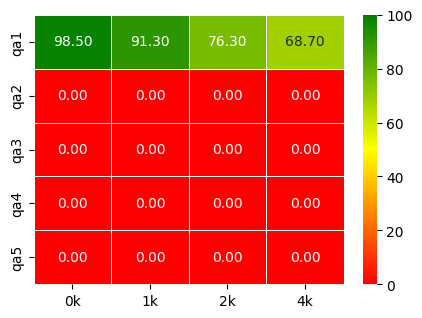

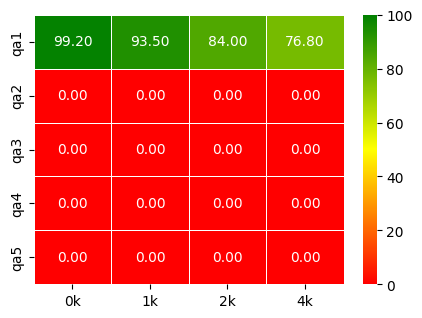

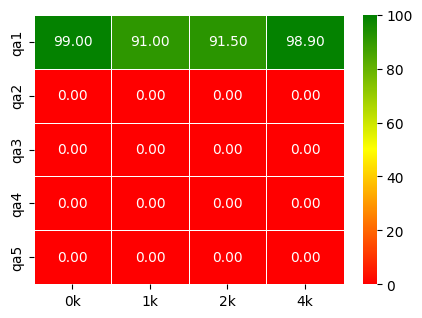

In [ ]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import matplotlib.pyplot as plt
import io
from PIL import Image
import numpy as np
import wandb
from transformers.integrations import WandbCallback
import matplotlib


def create_babilong_plot(
    report_dict,
    model_name="",
    dataset_name="babilongv2",
):
    rows = ["qa1", "qa2", "qa3", "qa4", "qa5"]
    cols = ["0k", "1k", "2k", "4k"]

    babilong_matrix = np.zeros((len(rows), len(cols)))

    for key in report_dict:
        if dataset_name in key:
            for i, row in enumerate(rows):
                for j, col in enumerate(cols):
                    if row in key and col in key:
                        babilong_matrix[i, j] = report_dict[key]

            cmap = LinearSegmentedColormap.from_list(
                "ryg", ["red", "yellow", "green"], N=256
            )

    fig, ax = plt.subplots(1, 1, figsize=(5 * 1, 3.5))
    sns.heatmap(
        babilong_matrix * 100,
        cmap=cmap,
        vmin=0,
        vmax=100,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        xticklabels=cols,
        yticklabels=rows,
        ax=ax,
    )
    ax.set_title(f"{model_name}", pad=20, y=0.95)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    buf.seek(0)
    pil_image = Image.open(buf)
    return pil_image


report_dict_raws = [
    # default
    {
        "babilongv2_qa1_0k_base": {
            "alias": "babilongv2_qa1_0k_base",
            "acc,none": 0.985,
            "acc_stderr,none": "N/A",
        },
        "babilongv2_qa1_1k_base": {
            "alias": "babilongv2_qa1_1k_base",
            "acc,none": 0.913,
            "acc_stderr,none": "N/A",
        },
        "babilongv2_qa1_2k_base": {
            "alias": "babilongv2_qa1_2k_base",
            "acc,none": 0.763,
            "acc_stderr,none": "N/A",
        },
        "babilongv2_qa1_4k_base": {
            "alias": "babilongv2_qa1_4k_base",
            "acc,none": 0.687,
            "acc_stderr,none": "N/A",
        },
    },
    # + " "
    {
        "babilongv2_qa1_0k_base": {
            "alias": "babilongv2_qa1_0k_base",
            "acc,none": 0.992,
            "acc_stderr,none": "N/A",
        },
        "babilongv2_qa1_1k_base": {
            "alias": "babilongv2_qa1_1k_base",
            "acc,none": 0.935,
            "acc_stderr,none": "N/A",
        },
        "babilongv2_qa1_2k_base": {
            "alias": "babilongv2_qa1_2k_base",
            "acc,none": 0.84,
            "acc_stderr,none": "N/A",
        },
        "babilongv2_qa1_4k_base": {
            "alias": "babilongv2_qa1_4k_base",
            "acc,none": 0.768,
            "acc_stderr,none": "N/A",
        },
    },
    # .replace("\n", " ").replace("  ", " ") + " "
    {
        "babilongv2_qa1_0k_base": {
            "alias": "babilongv2_qa1_0k_base",
            "acc,none": 0.99,
            "acc_stderr,none": "N/A",
        },
        "babilongv2_qa1_1k_base": {
            "alias": "babilongv2_qa1_1k_base",
            "acc,none": 0.91,
            "acc_stderr,none": "N/A",
        },
        "babilongv2_qa1_2k_base": {
            "alias": "babilongv2_qa1_2k_base",
            "acc,none": 0.915,
            "acc_stderr,none": "N/A",
        },
        "babilongv2_qa1_4k_base": {
            "alias": "babilongv2_qa1_4k_base",
            "acc,none": 0.989,
            "acc_stderr,none": "N/A",
        },
    },
]
for report_dict_raw in report_dict_raws:
    report_dict = {}
    ban_keys = ["stderr", "alias", "under"]
    for metric_name in report_dict_raw.keys():
        for key, value in report_dict_raw[metric_name].items():
            eval_key = f"eval_{metric_name}_{key}"
            if not any(ban_key in eval_key for ban_key in ban_keys):
                report_dict[eval_key] = value
    create_babilong_plot(report_dict=report_dict)